# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 94
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,c2450ad,1.978096,43.9,KEEP,baseline
1,1696063,1.114434,11.3,KEEP,"reduce batch size 2^19->2^16, device 128->32 f..."
2,8f289de,1.119292,11.3,DISCARD,increase MATRIX_LR 0.04->0.06
3,53879ec,1.124362,5.9,DISCARD,"halve batch size 2^16->2^15, device 32->16 for..."
4,babnhjz,1.141973,17.1,DISCARD,"increase DEPTH 8->10 (~86M params, fewer steps)"
5,bmocspnct,1.118847,11.3,DISCARD,WINDOW_PATTERN SSSL->L (all full attention)
6,bdnth9g28,1.115755,11.3,DISCARD,weight decay 0.2->0.0
7,br5wl1ymx,1.116369,11.3,DISCARD,"Adam beta1 0.8->0.9, embedding LR 0.6->0.3"
8,bo4jjxvq8,1.123336,11.3,DISCARD,MLP activation relu^2 -> SiLU
9,15b1edd,1.114312,11.3,KEEP,reduce MATRIX_LR 0.04->0.02


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    70
KEEP       24

Keep rate: 24/94 = 25.5%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (24 total):

  #  0  bpb=1.978096  mem=43.9GB  baseline
  #  1  bpb=1.114434  mem=11.3GB  reduce batch size 2^19->2^16, device 128->32 for more optimizer steps
  #  9  bpb=1.114312  mem=11.3GB  reduce MATRIX_LR 0.04->0.02
  # 15  bpb=1.110488  mem=11.3GB  RoPE base 10000->50000
  # 26  bpb=1.109812  mem=11.3GB  S-layer window 1024->512 (long_window//4) for faster attention, more steps
  # 27  bpb=1.105889  mem=11.3GB  S-layer window 512->256 (long_window//8) even more steps (1140)
  # 28  bpb=1.104112  mem=11.3GB  S-layer window 256->128 (long_window//16) 1159 steps
  # 29  bpb=1.103181  mem=11.3GB  S-layer window 128->64 (long_window//32) 1170 steps
  # 31  bpb=1.100676  mem=11.3GB  WINDOW_PATTERN SSSL->SSSSL (L at pos 4,7 vs 3,7) 1176 steps
  # 33  bpb=1.099409  mem=11.3GB  S-window 64->32 with SSSSL pattern (long_window//64) 1173 steps
  # 35  bpb=1.098821  mem=10.1GB  DEPTH 8->7 (same dim=512, 47.2M params, 1304 steps)
  # 38  bpb=1.098446  mem=10.1GB  S-window 48 

## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

NameError: name 'best' is not defined

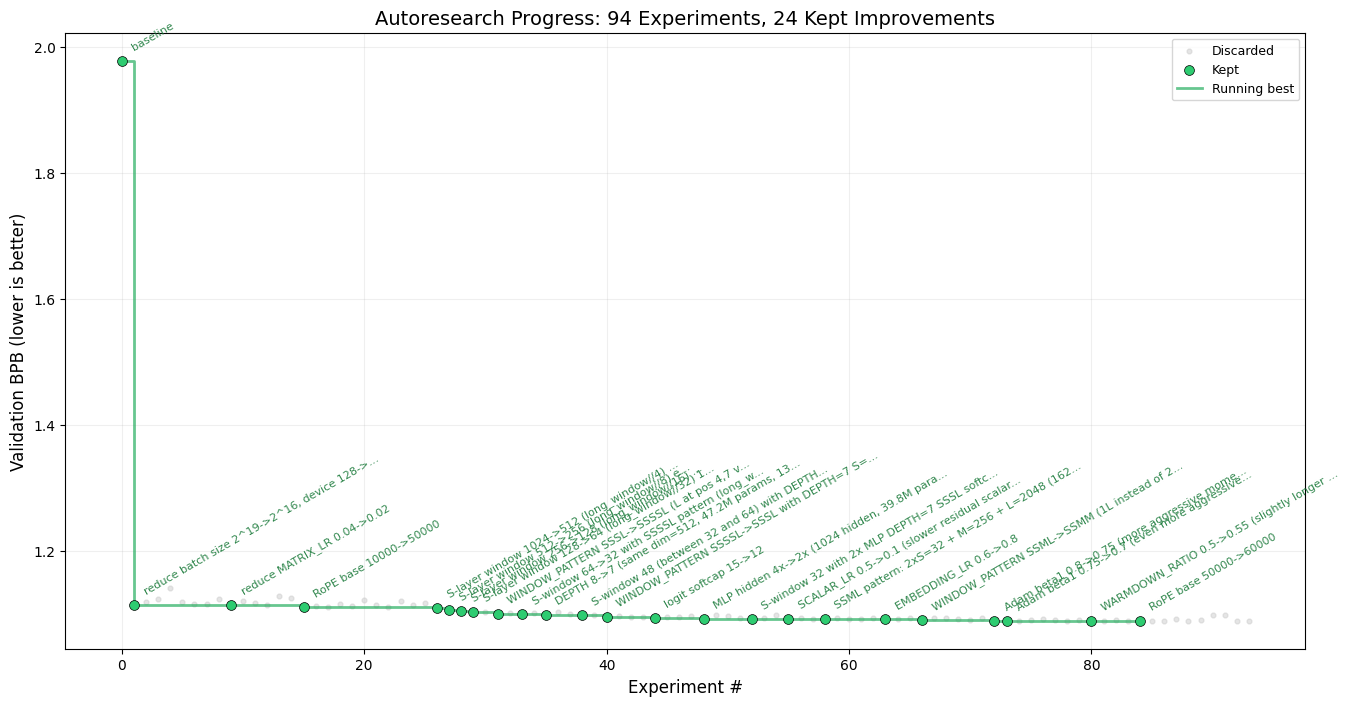

In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
margin = (baseline_bpb - best) * 0.15
ax.set_ylim(best - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.978096
Best val_bpb:      1.089244
Total improvement: 0.888852 (44.93%)
Best experiment:   RoPE base 50000->60000

Cumulative effort per improvement:
  Experiment #  0: bpb=1.978096  baseline
  Experiment #  1: bpb=1.114434  reduce batch size 2^19->2^16, device 128->32 for more optimizer steps
  Experiment #  9: bpb=1.114312  reduce MATRIX_LR 0.04->0.02
  Experiment # 15: bpb=1.110488  RoPE base 10000->50000
  Experiment # 26: bpb=1.109812  S-layer window 1024->512 (long_window//4) for faster attention, more steps
  Experiment # 27: bpb=1.105889  S-layer window 512->256 (long_window//8) even more steps (1140)
  Experiment # 28: bpb=1.104112  S-layer window 256->128 (long_window//16) 1159 steps
  Experiment # 29: bpb=1.103181  S-layer window 128->64 (long_window//32) 1170 steps
  Experiment # 31: bpb=1.100676  WINDOW_PATTERN SSSL->SSSSL (L at pos 4,7 vs 3,7) 1176 steps
  Experiment # 33: bpb=1.099409  S-window 64->32 with SSSSL pattern (long_window//64) 1173 steps
 

## Top Hits (Kept Experiments by Improvement)

In [6]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.863662  1.114434  reduce batch size 2^19->2^16, device 128->32 for more optimizer steps
   2  +0.003923  1.105889  S-layer window 512->256 (long_window//8) even more steps (1140)
   3  +0.003824  1.110488  RoPE base 10000->50000
   4  +0.003620  1.094826  WINDOW_PATTERN SSSSL->SSSL with DEPTH=7 S=48 (L at pos 3,6 vs 4,6) 1301 steps
   5  +0.002505  1.100676  WINDOW_PATTERN SSSL->SSSSL (L at pos 4,7 vs 3,7) 1176 steps
   6  +0.001777  1.104112  S-layer window 256->128 (long_window//16) 1159 steps
   7  +0.001560  1.092723  MLP hidden 4x->2x (1024 hidden, 39.8M params, 1634 steps)
   8  +0.001267  1.099409  S-window 64->32 with SSSSL pattern (long_window//64) 1173 steps
   9  +0.001258  1.090030  WINDOW_PATTERN SSML->SSMM (1L instead of 2L, 4S+2M+1L, 1674 steps)
  10  +0.000931  1.103181  S-layer window 128->64 (long_window//32) 1170 steps
  11  +0.000746  1.0